In [ ]:
!pip install numpy==1.26.4
!pip install pandas
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn
!pip install vit-keras

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import requests
from io import BytesIO

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 16

In [ ]:
!rm -f master.zip
!wget -O plant_dataset.zip https://github.com/spMohanty/PlantVillage-Dataset/archive/refs/heads/master.zip
!unzip plant_dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: PlantVillage-Dataset-master/raw/grayscale/Grape___Esca_(Black_Measles)/8ba71490-9d16-4e65-adf5-90f9d1d5653c___FAM_B.Msls 4031.JPG  
  inflating: PlantVillage-Dataset-master/raw/grayscale/Grape___Esca_(Black_Measles)/8bb24787-f86e-4c6a-90aa-cfebf35878ee___FAM_B.Msls 1024.JPG  
  inflating: PlantVillage-Dataset-master/raw/grayscale/Grape___Esca_(Black_Measles)/8bc43aa5-c8bf-45fa-b1b7-ed28a38e5e6a___FAM_B.Msls 4355.JPG  
  inflating: PlantVillage-Dataset-master/raw/grayscale/Grape___Esca_(Black_Measles)/8c02d3db-062d-433e-b76c-b1ab7d92f6a9___FAM_B.Msls 4360.JPG  
  inflating: PlantVillage-Dataset-master/raw/grayscale/Grape___Esca_(Black_Measles)/8c04107c-3a30-498d-8dbb-e9c8dbc331fe___FAM_B.Msls 1348.JPG  
  inflating: PlantVillage-Dataset-master/raw/grayscale/Grape___Esca_(Black_Measles)/8c3515a7-2962-41f4-80e0-f9b399054f9c___FAM_B.Msls 1346.JPG  
  inflating: PlantVillage-Dataset-master/raw/grayscale/Grape___Esca_(Black_Meas

In [ ]:
dataset_path = "/content/PlantVillage-Dataset-master/raw/color"

In [ ]:

dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
print("Classes:", len(class_names))

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Classes: 38


In [ ]:
# Dataset optimization
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = dataset.take(500).prefetch(buffer_size=AUTOTUNE)

val_dataset = val_dataset.take(100).prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# Apply augmentation
x = data_augmentation(inputs)

# EfficientNet preprocessing
x = tf.keras.applications.efficientnet.preprocess_input(x)

# Pass through EfficientNet
x = base_model(x, training=False)

# Classification head
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,392,393 (16.76 MB)

 Trainable params: 340,262 (1.30 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.9223 - loss: 0.2409 - val_accuracy: 0.9456 - val_loss: 0.1644
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9334 - loss: 0.2149 - val_accuracy: 0.9500 - val_loss: 0.1512
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9357 - loss: 0.2008 - val_accuracy: 0.9506 - val_loss: 0.1453
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9460 - loss: 0.1807 - val_accuracy: 0.9563 - val_loss: 0.1438
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9362 - loss: 0.2065 - val_accuracy: 0.9563 - val_loss: 0.1405
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9416 - loss: 0.1750 - val_accuracy: 0.9556 - val_loss: 0.1335
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9520 - loss: 0.1578 - val_accuracy: 0.9569 - val_loss: 0.1335
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9458 - loss: 0.1678 - 

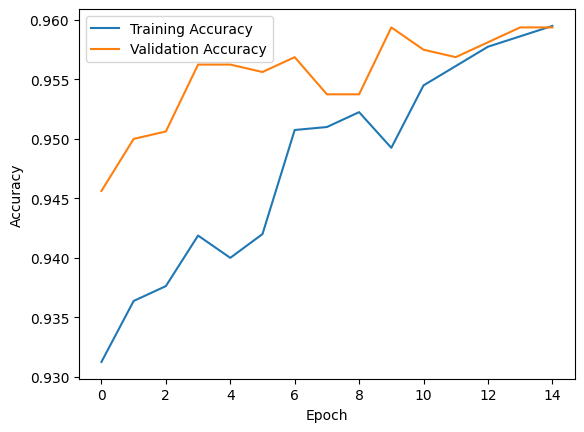

In [ ]:
# Accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import json
import pickle
import matplotlib.pyplot as plt

# SAVE MODEL
model.save("plant_disease_model.keras")

# SAVE TRAINING HISTORY
with open("training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

# SAVE CLASS NAMES
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

# SAVE ACCURACY GRAPH
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("accuracy_graph.png")
plt.close()

# SAVE LOSS GRAPH
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("loss_graph.png")
plt.close()

print("✅ Model, history, class names, and graphs saved successfully")

✅ Model, history, class names, and graphs saved successfully


✅ Model and data loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


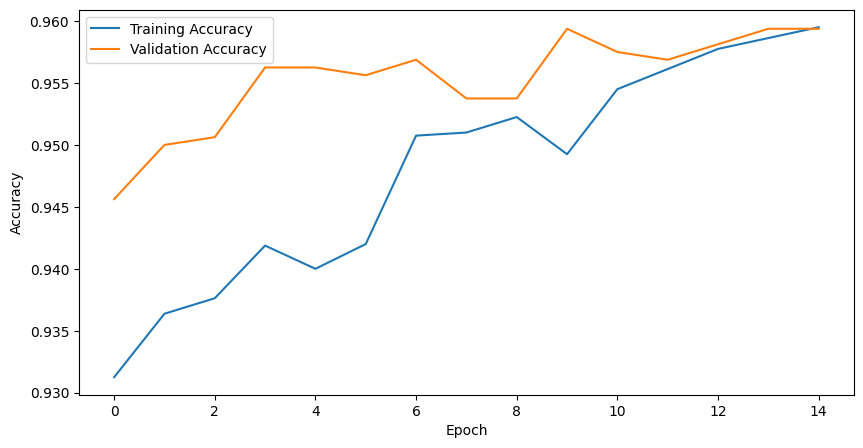

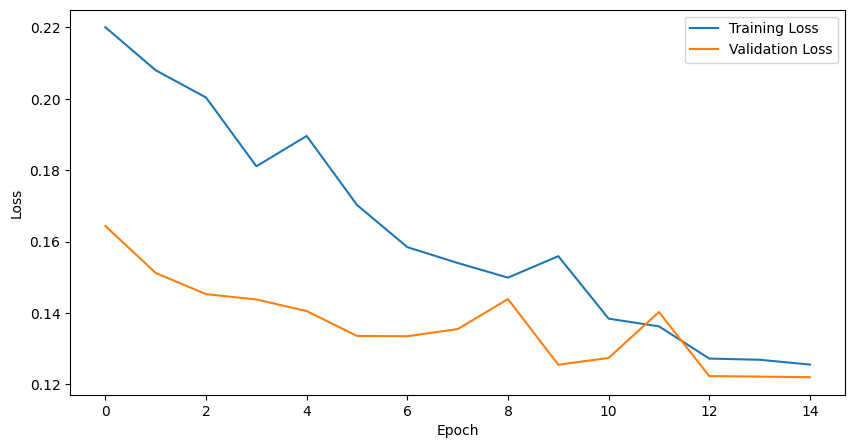

In [ ]:
import json
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# LOAD MODEL
model = load_model("plant_disease_model.keras")

# LOAD TRAINING HISTORY
with open("training_history.pkl", "rb") as f:
    history = pickle.load(f)

# LOAD CLASS NAMES
with open("class_names.json") as f:
    class_names = json.load(f)

print("✅ Model and data loaded successfully")

# SHOW ACCURACY GRAPH
plt.figure(figsize=(10,5))
plt.plot(history['accuracy'], label="Training Accuracy")
plt.plot(history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# SHOW LOSS GRAPH
plt.figure(figsize=(10,5))
plt.plot(history['loss'], label="Training Loss")
plt.plot(history['val_loss'], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(val_dataset)

print("Validation Accuracy:", test_acc)

100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.9582 - loss: 0.1230
Validation Accuracy: 0.9606249928474426


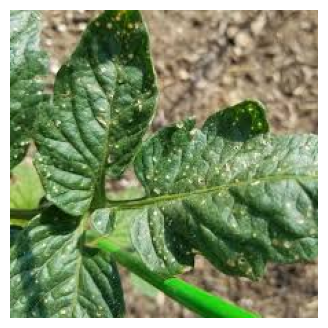

🌿 Plant : Tomato
🦠 Disease : Late blight
🔬 Cause : Fungus
📊 Confidence : 99.86 %

💊 Treatment :
• Apply fungicide spray
• Remove infected leaves
• Improve air circulation


In [ ]:
def predict_disease(image_path):

    # Load image
    if image_path.startswith("http"):
        response = requests.get(image_path)
        img = tf.keras.utils.load_img(
            BytesIO(response.content),
            target_size=(IMAGE_SIZE, IMAGE_SIZE)
        )
    else:
        img = tf.keras.utils.load_img(
            image_path,
            target_size=(IMAGE_SIZE, IMAGE_SIZE)
        )

    # Show image
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # Convert image → array
    img_array = tf.keras.utils.img_to_array(img)

    # Normalize (CNN input)
    img_array = img_array / 255.0

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction using CNN model
    predictions = model.predict(img_array, verbose=0)

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]

    confidence = float(np.max(predictions) * 100)

    # Split plant and disease
    parts = predicted_class.split("___")
    plant = parts[0]
    disease = parts[1] if len(parts) > 1 else "Unknown"
    disease = disease.replace("_"," ")

    # Detect cause
    disease_lower = disease.lower()

    if "virus" in disease_lower:
        cause = "Virus"
    elif "bacterial" in disease_lower:
        cause = "Bacteria"
    elif "blight" in disease_lower or "rust" in disease_lower or "mold" in disease_lower:
        cause = "Fungus"
    elif "healthy" in disease_lower:
        cause = "No Disease"
    else:
        cause = "Unknown"

    # Treatments
    treatments = {
        "Fungus": [
            "Apply fungicide spray",
            "Remove infected leaves",
            "Improve air circulation"
        ],
        "Bacteria": [
            "Use copper-based bactericide",
            "Remove infected plants",
            "Avoid overhead watering"
        ],
        "Virus": [
            "Remove infected plants",
            "Control insect vectors",
            "Use resistant plant varieties"
        ],
        "No Disease": [
            "Plant is healthy",
            "Maintain proper watering",
            "Use balanced fertilizers"
        ]
    }

    treatment = treatments.get(cause, ["Consult agriculture expert"])

    return plant, disease, cause, confidence, treatment
# image_url = "https://homegarden-cahnr.media.uconn.edu/wp-content/uploads/sites/3479/2022/02/apple-rust-disease_3_3497055209.jpeg"
# image_url = "https://nebraskacorn.gov/wp-content/uploads/2025/09/Gosss-wilt-and-leaf-blight-scaled.jpg"
image_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSslII8zy5gnSR3jXaU7_JDV3PbBHpdaTtgTQ&s"

plant, disease, cause, conf, treatment = predict_disease(image_url)

print("🌿 Plant :", plant)
print("🦠 Disease :", disease)
print("🔬 Cause :", cause)
print("📊 Confidence :", round(conf,2), "%")

print("\n💊 Treatment :")
for t in treatment:
    print("•", t)

In [ ]:
# Evaluate using validation set
test_loss, test_acc = model.evaluate(val_dataset)

print(f"Validation Accuracy: {test_acc:.2%}")

# Compare to validation accuracy during training
val_acc = history['val_accuracy'][-1]

print(f"Training Validation Accuracy: {val_acc:.2%}")

if test_acc < val_acc - 0.1:
    print("⚠️ Overfitting detected")
elif test_acc < 0.7:
    print("⚠️ Underfitting detected")
else:
    print("✅ Good generalization")

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9617 - loss: 0.1179
Validation Accuracy: 95.81%
Training Validation Accuracy: 95.94%
✅ Good generalization
